In [ ]:
# ============================================================
# C1-Environment set up
# ============================================================

# Clone repository from GitHub
!git clone https://github.com/marcndo/churn-predictor.git

# Move to project directory
import os
os.chdir("churn-predictor")

print("Current directory", os.getcwd())
print("Directory files", os.listdir())

Cloning into 'churn-predictor'...
remote: Enumerating objects: 14, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 14 (delta 0), reused 14 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (14/14), 164.42 KiB | 1.57 MiB/s, done.
Current directory /content/churn-predictor
Directory files ['tests', 'src', 'notebooks', '.gitignore', 'data', 'requirements.txt', '.git', 'README.md']


In [ ]:
# ===========================================================
# C2-Install dependencies
# ===========================================================
!pip install -r requirements.txt -q

import pandas as pd
import numpy as np
import sklearn
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("xgboos:", xgb.__version__)


pandas: 2.2.2
scikit-learn: 1.6.1
xgboos: 3.2.0


In [ ]:
# ==========================================
# C3-Download data set
# ==========================================

import os

# Create both subfolders before anything tries to write into them
os.makedirs('data/raw', exist_ok=True)
os.makedirs('data/plots', exist_ok=True)
os.makedirs('models', exist_ok=True)

print("Folders ready:", os.listdir('data'))
!wget -q "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv" -O data/raw/Telco-Customer-Churn.csv
import os
file_size = os.path.getsize("data/raw/Telco-Customer-Churn.csv")
print(f"Data Downloaded:{file_size} bytes")
print(f"Location: data/raw/Telco-Customer-Churn.csv")


Data Downloaded:970457 bytes
Location: data/Telco-Customer-Churn.csv


# Exploratory Data Analysis(EDA)
## Question1: What does this dataset contain?


In [ ]:
# ==========================================
# C4-Download data set
# Question: What are we working with?
# ==========================================
#Load the data
df = pd.read_csv("data/raw/Telco-Customer-Churn.csv")

#Shape: How many rows and column?
print("Shape", df.shape)
print()

# Columns names and data type
print("Colums names and types")
print(df.dtypes)
print()

# Display first 5 rows
df.head()


Shape (7043, 21)

Colums names and types
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


* CustomerID should not be consider a feature, it's to random
* gender: Client's personal information not linked to telecom services
* SeniorCitizen: Client's status

## Question 2. Are there data quality problems?

In [ ]:
# ==========================================
# C5- Missing values and duplicates.
# Question: Is the data clean or does it has duplicate?
# ==========================================

# Check missing values for each column
print("Missing values per column: ")
print(df.isnull().sum())
print()

# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"Duplicate row:{duplicates}")
print()


# Check TotalCharge
print("TotalCharge column type", df["TotalCharges"].dtype)
print("Sample TotalCharges values")
print(df["TotalCharges"].head(10).tolist())



Missing values per column: 
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicate row:0

TotalCharge column type object
Sample TotalCharges values
['29.85', '1889.5', '108.15', '1840.75', '151.65', '820.5', '1949.4', '301.9', '3046.05', '3487.95']


* TotalCharges is stored as a string not integers

### Question 3 How balance is the dataset





Churn distribution
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn percentage
Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64



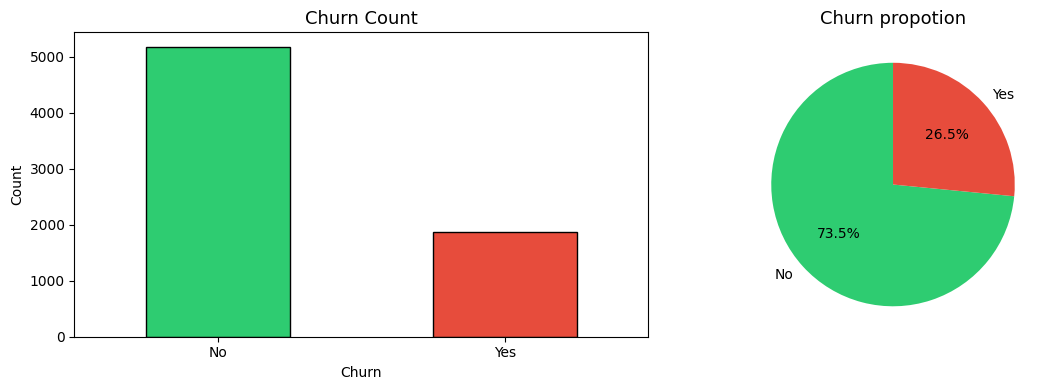

Plot saved.


In [ ]:
# Row count
print("Churn distribution")
print(df["Churn"].value_counts())
print()

# Percentage
print("Churn percentage")
print(df["Churn"].value_counts(normalize=True).mul(100).round(1))
print()

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
df["Churn"].value_counts().plot(
    kind = "bar",
    ax = axes[0],
    color=['#2ecc71', '#e74c3c'],
    edgecolor='black'
)
axes[0].set_title("Churn Count", fontsize=13)
axes[0].set_xlabel("Churn")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=0)

df["Churn"].value_counts().plot(
    kind = "pie",
    ax = axes[1],
    colors=['#2ecc71', '#e74c3c'],
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title("Churn propotion", fontsize=13)
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('data/plots/churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved.")

About 74% of customer do not churn where 26% do churn. This means that if a model is build with this inbalance dataset and it keeps predicting no churn even without considering the other features, it would be about 74% correct all the times. It never predicts a churn customer. This explain why *Accuracy* is not the right metrics here to meansure performance.
* Precision: Of all the customers flagged as likely to churn, what fraction actually churn?
* Recall: Of all the customers who churned what fraction did the model catch?
* F1 score: Hormonic mean of precision and recall. It balances both. This would be our metric for this project.

* Accuracy is a missleading metric here because the model performs well only on the majority class, thus treating the minority as noise.
* The model can keeping predicting only the majority class and still archieve about 74% accuracy.

### Question4: Which features relates more strongly to Churn




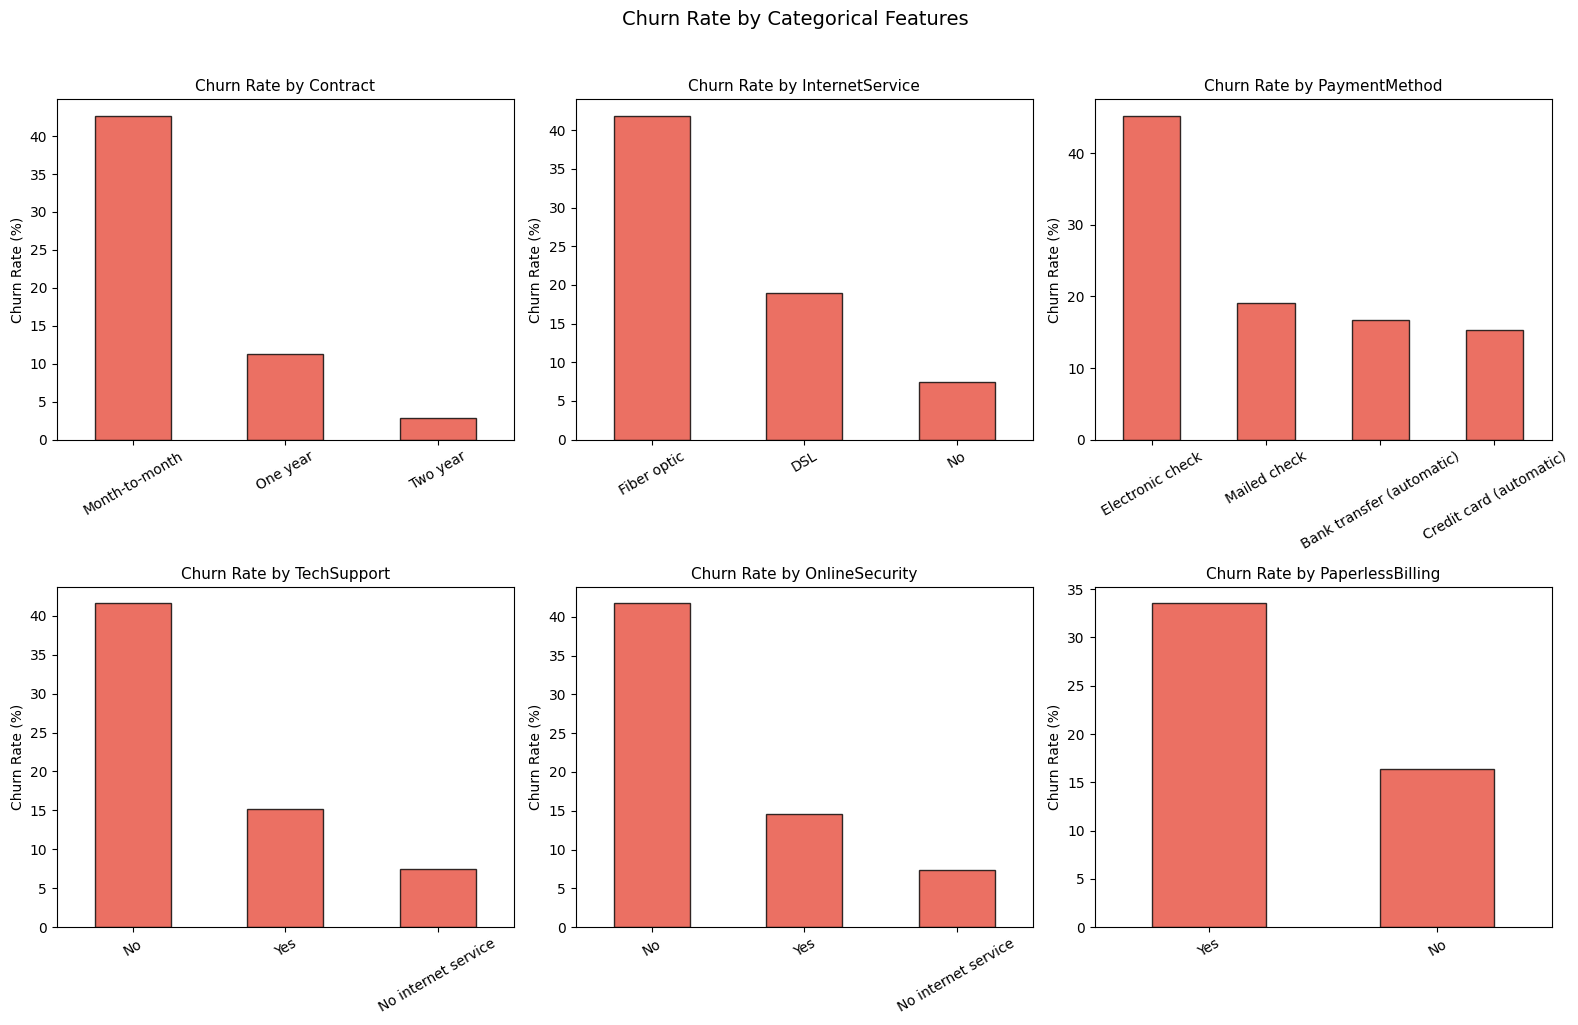

Plot saved.


In [ ]:
# ============================================================
# CELL 7 — Categorical features vs churn
# Question: Which service and contract features predict churn?
# ============================================================

# Categorical features more likely to matter.
categorical_features = [
    'Contract', 'InternetService', 'PaymentMethod',
    'TechSupport', 'OnlineSecurity', 'PaperlessBilling'
]
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    churn_rates = df.groupby(col)['Churn'].apply(
        lambda x: (x == 'Yes').mean() * 100
    ).sort_values(ascending=False)

    churn_rates.plot(
        kind='bar',
        ax=axes[i],
        color='#e74c3c',
        edgecolor='black',
        alpha=0.8
    )
    axes[i].set_title(f'Churn Rate by {col}', fontsize=11)
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].set_xlabel('')

plt.suptitle('Churn Rate by Categorical Features', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('data/plots/categorical_churn_rates.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

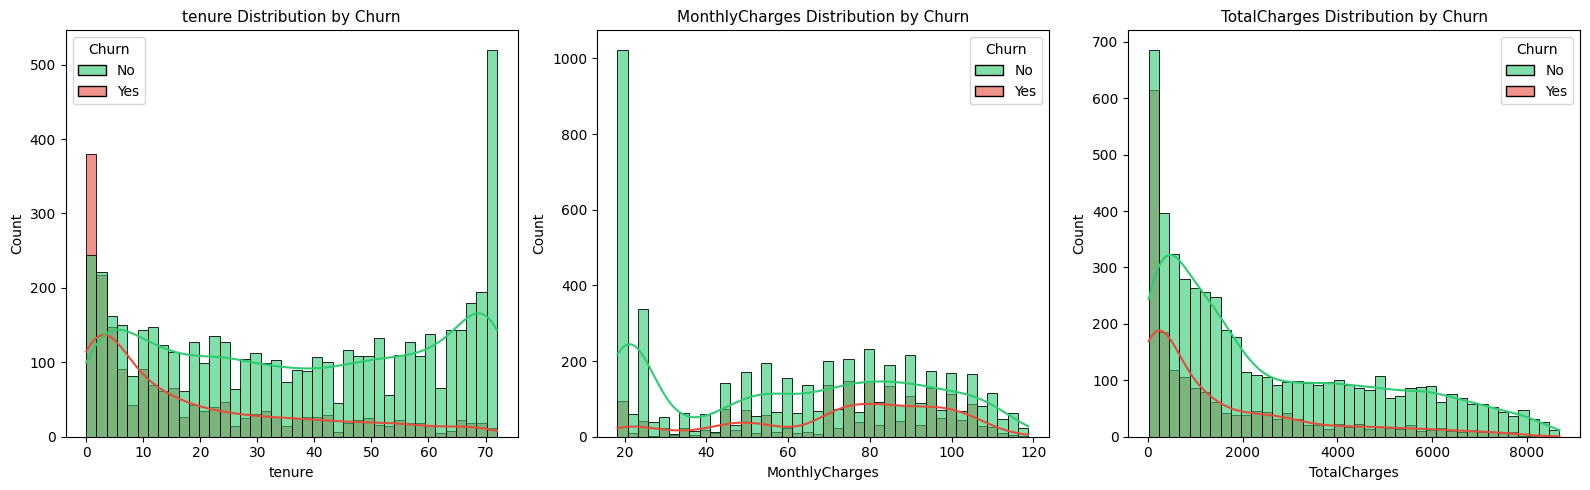

Plot saved.


In [ ]:
# ============================================================
# CELL 8 — Numerical features vs churn
# Question: How do tenure, charges, and usage differ between
#           customers who churn and those who stay?
# ============================================================

numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Convert TotalCharges to numeric first — fixing the data quality issue
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(numerical_features):
    sns.histplot(
        data=df,
        x=col,
        hue='Churn',
        bins=40,
        kde=True,
        ax=axes[i],
        palette={'Yes': '#e74c3c', 'No': '#2ecc71'},
        alpha=0.6
    )
    axes[i].set_title(f'{col} Distribution by Churn', fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.savefig('data/raw/numerical_churn_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

* Month-to-month contract turns to churn more than customers locked in a long term contract
* Customer who churn turns to be new customers. Long tenured customers are loyal.
* Customers who churn turn to pay higher monthly charges. This could mean they're not getting value for money.

Question5. Correlation between numerical features.

Correlation matrix:
                tenure  MonthlyCharges  TotalCharges
tenure            1.00            0.25          0.83
MonthlyCharges    0.25            1.00          0.65
TotalCharges      0.83            0.65          1.00



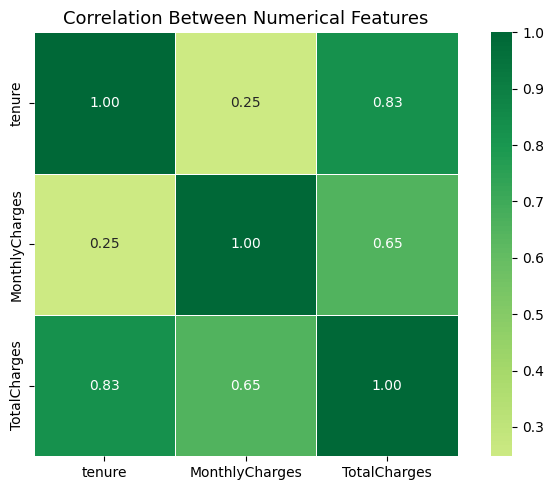

Plot saved.


In [ ]:
# ============================================================
# CELL 9 — Correlation analysis
# Question: Are any numerical features redundant with each other?
# ============================================================

num_df = df[['tenure', 'MonthlyCharges', 'TotalCharges']].copy()
# Compute correlation matrix
corr_matrix = num_df.corr()
print("Correlation matrix:")
print(corr_matrix.round(2))
print()

# Visualize as heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    square=True,
    linewidths=0.5
)
plt.title('Correlation Between Numerical Features', fontsize=13)
plt.tight_layout()
plt.savefig('data/raw/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")


* TotalCharge is highly correlated to tenure and MonthlyCharges.
* This makes sense since TotalCharge is the product of MonthlyCharge and tenure.
* Higly corrected features($multicollinearity$) gives the model redundant information.